# Vector-less Graph RAG

In traditional RAG, we split documents into chunks and use an **embedding model** to store them in a vector database. During retrieval, we find chunks semantically similar to the question using vector math.

**Graph RAG** takes a different approach. It builds a **Knowledge Graph** of entities (nodes) and their relationships (edges) extracted from the text. 

In a **Vector-less Graph RAG**, we completely eliminate the embedding model and vector database. Instead, we rely entirely on the graph structure:
1. **Extraction:** Use an LLM to extract entities and relations from the text to build the graph.
2. **Retrieval:** Extract entities from the user's question and find matching nodes in the graph using keyword/string matching (no vectors).
3. **Context:** Traverse the graph to find neighboring nodes and relationships, forming a "subgraph" of context.
4. **Generation:** Pass this graph context to the LLM to answer the question.

### 1. Setup and Dependencies
We need `networkx` to build and manage our graph in memory. We'll use the same `llama3.2:3b` model for both extracting the graph and answering the questions.

In [ ]:
!pip install networkx matplotlib pypdf langchain_ollama langchain_community

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from langchain_ollama import OllamaLLM
from langchain_community.document_loaders import PyPDFLoader
import json
import re

print("🔧 Loading model...")
llm = OllamaLLM(model="llama3.2:3b")
print("✅ Model ready")

🔧 Loading model...
✅ Model ready


### 2. Load the Data
We load **page 0 and page 1** from the Attention paper PDF and combine them into a single text block. Processing more pages gives the LLM more facts to extract into the Knowledge Graph, resulting in richer retrieval.

In [10]:
loader = PyPDFLoader("NIPS-2017-attention-is-all-you-need-Paper.pdf")
pages = loader.load()

# Combine page 0 and page 1 into a single text block
text_data = pages[0].page_content + "\n" + pages[1].page_content
print(f"📄 Total characters from pages 0 & 1: {len(text_data)}")
print(f"\n--- Page 0 preview ---\n{pages[0].page_content[:300]}\n")
print(f"--- Page 1 preview ---\n{pages[1].page_content[:300]}\n")

📄 Total characters from pages 0 & 1: 7157

--- Page 0 preview ---
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗†
University of Toronto
aid

--- Page 1 preview ---
Recurrent models typically factor computation along the symbol positions of the input and output
sequences. Aligning the positions to steps in computation time, they generate a sequence of hidden
statesht, as a function of the previous hidden stateht−1 and the input for positiont. This inherently
se



### 3. Knowledge Graph Extraction
Here we ask the LLM to read the text and extract triplets: `(Subject, Relation, Object)`. 
These triplets represent the facts in the text.

In [11]:
extraction_prompt = """
You are an expert data extractor. Your task is to extract relationships between entities in the given text.
Format the output as a JSON list of objects, where each object has three keys: "subject", "relation", "object".
Only output valid JSON. Do not include any other text.

Example:
Text: "The Transformer is a new network architecture proposed by Google Brain."
Output:
[
  {{"subject": "Transformer", "relation": "is a", "object": "new network architecture"}},
  {{"subject": "Transformer", "relation": "proposed by", "object": "Google Brain"}}
]

Text:
{text}

Output:
"""

def extract_triplets(text):
    print("⏳ Extracting triplets using LLM...")
    response = llm.invoke(extraction_prompt.format(text=text))
    
    # Simple regex to extract JSON array if the LLM adds markdown formatting
    match = re.search(r'\[.*\]', response, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except:
            pass
    return []

from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=150
)
chunks = splitter.split_text(text_data)
print(f"📦 Split text into {len(chunks)} chunks for LLM processing...")

all_triplets = []
for i, chunk in enumerate(chunks):
    print(f"\n--- Chunk {i+1}/{len(chunks)} ---")
    triplets = extract_triplets(chunk)
    all_triplets.extend(triplets)

print(f"\n✅ Extracted total {len(all_triplets)} relations.")
for t in all_triplets[:5]:
    print(t)

# Update the variable name for the next cell that builds the graph
triplets = all_triplets


📦 Split text into 6 chunks for LLM processing...

--- Chunk 1/6 ---
⏳ Extracting triplets using LLM...

--- Chunk 2/6 ---
⏳ Extracting triplets using LLM...

--- Chunk 3/6 ---
⏳ Extracting triplets using LLM...

--- Chunk 4/6 ---
⏳ Extracting triplets using LLM...

--- Chunk 5/6 ---
⏳ Extracting triplets using LLM...

--- Chunk 6/6 ---
⏳ Extracting triplets using LLM...

✅ Extracted total 62 relations.
{'subject': 'Transformer', 'relation': 'proposed by', 'object': 'Google Brain'}
{'subject': 'Transformer', 'relation': 'based solely on attention mechanisms', 'object': 'entirely'}
{'subject': 'attention mechanism', 'relation': 'connects the encoder and decoder through', 'object': 'the Transformer'}
{'subject': 'encoder', 'relation': 'and a decoder', 'object': 'are based on complex recurrent or convolutional neural networks'}
{'subject': 'decoder', 'relation': 'and a decoder', 'object': 'are based on complex recurrent or convolutional neural networks'}


### 4. Build and Visualize the Graph
We use `networkx` to create a directed graph. Nodes are the subjects and objects. Directed edges are the relations connecting them.

✅ Graph built with 67 nodes and 46 edges.


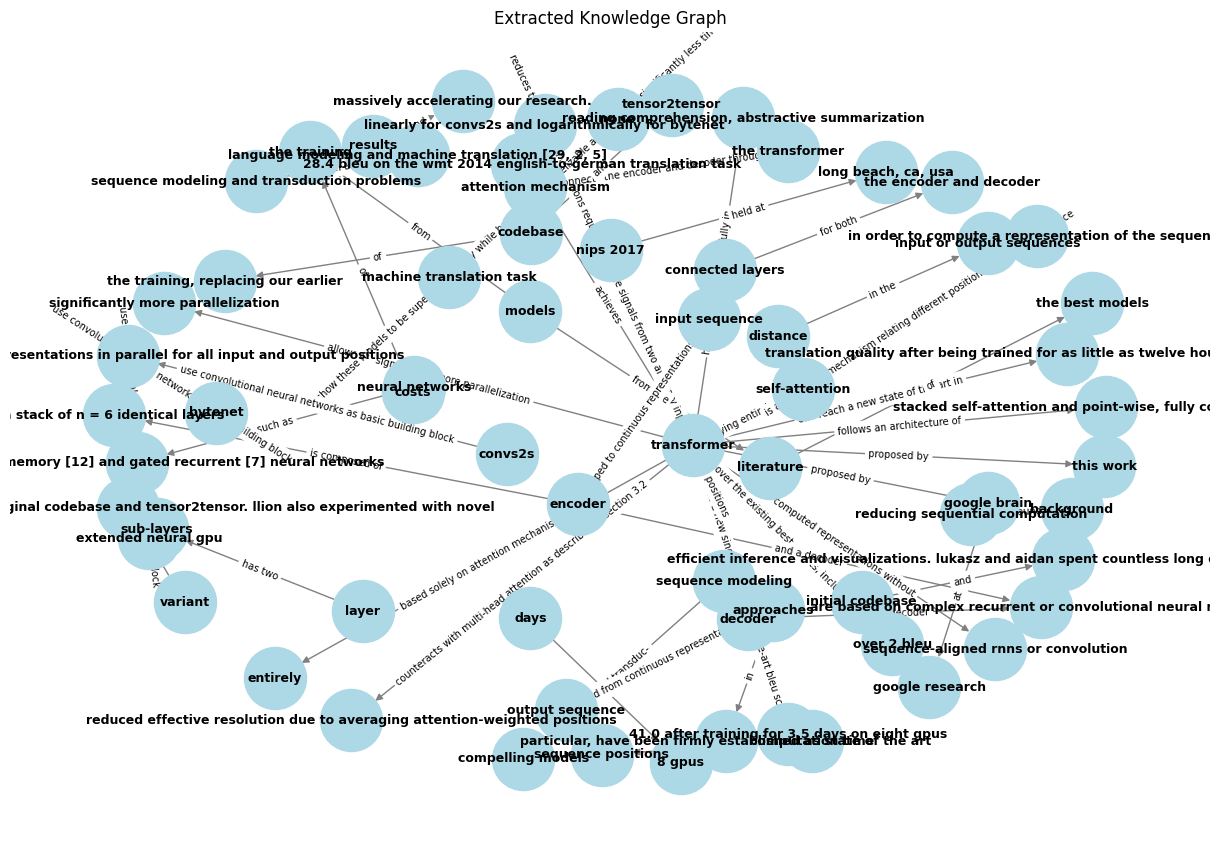

In [12]:
G = nx.DiGraph()

for triplet in triplets:
    subj = triplet.get("subject", "").strip().lower()
    obj = triplet.get("object", "").strip().lower()
    rel = triplet.get("relation", "").strip().lower()
    
    if subj and obj and rel:
        G.add_node(subj)
        G.add_node(obj)
        G.add_edge(subj, obj, label=rel)

print(f"✅ Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Visualization
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.5) # k controls node spacing
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=9, font_weight='bold', edge_color='gray')
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Extracted Knowledge Graph")
plt.show()

### 5. Vector-less Retrieval
To retrieve context without vectors, we:
1. Extract the main entities from the user's query.
2. Perform keyword/string matching to find these entities in our graph nodes.
3. Extract the **1-hop subgraph** (immediate neighbors and edges) around the matched nodes.
This subgraph represents the retrieved facts!

In [13]:
entity_extraction_prompt = """
Extract the main entities from the following question as a comma-separated list.
Question: {question}
Entities:
"""

def retrieve_context(question, graph):
    print(f"❓ Question: {question}")
    
    # 1. Extract entities from question
    entities_response = llm.invoke(entity_extraction_prompt.format(question=question))
    question_entities = [e.strip().lower() for e in entities_response.split(',') if e.strip()]
    print(f"🔍 Question Entities: {question_entities}")
    
    # 2. Find matching nodes in the graph (Vector-less string match)
    matched_nodes = []
    for q_entity in question_entities:
        for node in graph.nodes():
            if q_entity in node or node in q_entity:
                matched_nodes.append(node)
                
    matched_nodes = list(set(matched_nodes))
    print(f"🎯 Matched Graph Nodes: {matched_nodes}")
    
    # 3. Extract subgraph facts
    context_facts = []
    for node in matched_nodes:
        # Facts where matched node is the subject
        for neighbor in graph.successors(node):
            rel = graph.edges[node, neighbor]['label']
            context_facts.append(f"{node} --[{rel}]--> {neighbor}")
        # Facts where matched node is the object
        for neighbor in graph.predecessors(node):
            rel = graph.edges[neighbor, node]['label']
            context_facts.append(f"{neighbor} --[{rel}]--> {node}")
            
    context_facts = list(set(context_facts))
    
    print(f"📋 Retrieved {len(context_facts)} graph facts")
    for fact in context_facts:
        print(f"  - {fact}")
        
    return "\n".join(context_facts)

### 6. Generation
We inject the retrieved graph facts into the prompt and ask the LLM to generate the final answer.

In [14]:
qa_prompt = """You are an expert AI research assistant.
Answer the question using ONLY the knowledge graph facts provided below.
Be direct and use the facts to form your answer.
If the answer is not in the facts, say "I don't have enough information in the graph to answer that."

Knowledge Graph Facts:
{context}

Question: {question}

Answer:"""

def ask_graph_rag(question, graph):
    context = retrieve_context(question, graph)
    
    if not context:
        print("\n🤖 Answer: I don't have enough information in the graph to answer that (No matching nodes found).\n")
        print("─"*60 + "\n")
        return
        
    prompt = qa_prompt.format(context=context, question=question)
    response = llm.invoke(prompt)
    
    print(f"\n🤖 Answer:\n{response}")
    print("\n" + "─"*60 + "\n")

# Let's ask a question!
ask_graph_rag("Who is affiliated with Google Brain?", G)

❓ Question: Who is affiliated with Google Brain?
🔍 Question Entities: ['there are no entities mentioned in the question. it appears to be incomplete or missing relevant information about the entities related to google brain. if you provide more context or details', "i'd be happy to help extract the main entities for you!"]
🎯 Matched Graph Nodes: ['google brain']
📋 Retrieved 2 graph facts
  - transformer --[proposed by]--> google brain
  - google brain --[at]--> google research

🤖 Answer:
Google Research.

────────────────────────────────────────────────────────────



In [16]:
ask_graph_rag("What are the dominant sequence transduction models based on?", G)

❓ Question: What are the dominant sequence transduction models based on?
🔍 Question Entities: ['there is no information provided in the question to extract entities from. the text only contains "what are the dominant sequence transduction models based on?" without any specific details or context that would allow me to identify entities. if you provide more context or information', "i'd be happy to help you extract main entities as a comma-separated list."]
🎯 Matched Graph Nodes: ['models']
📋 Retrieved 2 graph facts
  - models --[from the]--> literature
  - models --[from]--> the training

🤖 Answer:
Based on the knowledge graph facts, I can infer that the dominant sequence transduction models are based on the concepts of "literature" and "the training". However, there is no explicit information about what these concepts represent.

Let me try to make a connection. Since "models" are mentioned as being derived from both "literature" and "the training", I can infer that the dominant seque

In [19]:
ask_graph_rag("What is difference between transformers and RNN?", G)

❓ Question: What is difference between transformers and RNN?
🔍 Question Entities: ['there are no entities to extract from your original message', 'only a question. however', 'i can provide you with a general outline of the main entities related to the topic:\n\ntransformers', "rnn (recurrent neural network)\n\nif you'd like me to clarify or expand on these entities", 'please let me know!']
🎯 Matched Graph Nodes: ['transformer']
📋 Retrieved 14 graph facts
  - transformer --[improves over the existing best results, including ensembles, by]--> over 2 bleu
  - transformer --[based solely on attention mechanisms]--> entirely
  - transformer --[counteracts with multi-head attention as described in section 3.2]--> reduced effective resolution due to averaging attention-weighted positions
  - transformer --[proposed by]--> google brain
  - transformer --[follows an architecture of]--> stacked self-attention and point-wise, fully connected layers
  - transformer --[can reach a new state of the 

In [20]:
ask_graph_rag("What is this paper about, attention is all you need?", G)

❓ Question: What is this paper about, attention is all you need?
🔍 Question Entities: ['it seems like there\'s not enough information provided. the text you\'ve given doesn\'t mention any specific entities or content related to "what is this paper about', 'attention is all you need?".\n\nhowever', 'i can provide some general context based on my knowledge of the topic. "attention is all you need" is a paper published in 2017 by vaswani et al.', 'which introduced the transformer architecture for machine translation tasks. the main entities mentioned in that context are:\n\ntransformers\nmachine learning\nnatural language processing (nlp)\ndeep learning\n\nif you could provide more information or clarify what "this paper" refers to', "i'd be happy to help extract entities from it."]
🎯 Matched Graph Nodes: ['the transformer', 'machine translation task', 'transformer']
📋 Retrieved 16 graph facts
  - transformer --[improves over the existing best results, including ensembles, by]--> over 2 b

### Why use Vector-less Graph RAG?

**Pros:**
1. **Exact Precision**: No fuzziness from vector similarity. If you ask about "Google Brain", you get exact facts linked to "Google Brain".
2. **Explainability**: You can easily inspect the graph to see exactly *why* a fact was retrieved (e.g., node A is connected to node B via relation R).
3. **Multi-hop Reasoning**: It's easier to traverse multiple relationships (e.g., A -> B -> C) than to rely on vector similarity to bridge concepts.

**Cons:**
1. **Graph Building is Slow & Expensive**: Extracting triplets for a whole document takes a massive amount of LLM calls.
2. **Rigid Matching**: If the question asks for "Neural Nets" but the graph node is "Neural Networks", string matching might fail (unlike semantic vector matching). You often need an LLM to normalize entities or use a hybrid approach (Graph + Vectors).